In [1]:
import pandas as pd


def _scale_columns(df, prefix, include_totals):
    columns = [col for col in df.columns if col.startswith(prefix)]
    if not include_totals:
        total_column = f"{prefix[:-1]}_Total"
        columns = [col for col in columns if col != total_column]
    return columns


def load_and_split_combined_data(csv_path="combined_simulated.csv", include_totals=True):
    df = pd.read_csv(csv_path)

    rses_columns = _scale_columns(df, "RSES_", include_totals)
    rssis_columns = _scale_columns(df, "RSSIS_", include_totals)
    iss_columns = _scale_columns(df, "ISS_", include_totals)

    rses = df.loc[:, rses_columns].copy()
    rssis = df.loc[:, rssis_columns].copy()
    iss = df.loc[:, iss_columns].copy()

    used_columns = set(rses.columns) | set(rssis.columns) | set(iss.columns)
    covariates = df.loc[:, ~df.columns.isin(used_columns)].copy()

    return df, rses, rssis, iss, covariates


df, rses, rssis, iss, covariates = load_and_split_combined_data(
    "combined_simulated.csv",
    include_totals=False,
)

print(f"full data shape: {df.shape}")
print(f"rses shape: {rses.shape}")
print(f"rssis shape: {rssis.shape}")
print(f"iss shape: {iss.shape}")
print(f"covariates shape: {covariates.shape}")

print("\nCovariate columns:")
print(covariates.columns.tolist())

rses.head(), rssis.head(), iss.head(), covariates.head()

full data shape: (394, 77)
rses shape: (394, 10)
rssis shape: (394, 36)
iss shape: (394, 24)
covariates shape: (394, 7)

Covariate columns:
['RSES_Total', 'RSSIS_Total', 'ISS_Total', 'Gender', 'Academic_Year', 'TOPIK_Level', 'Economic_Status']


(   RSES_1  RSES_2  RSES_3_REV  RSES_4  RSES_5_REV  RSES_6  RSES_7  RSES_8_REV  \
 0       3       4           4       4           1       4       4           4   
 1       4       4           2       4           1       3       4           1   
 2       4       3           1       4           2       4       4           1   
 3       3       4           1       2           1       3       4           4   
 4       2       4           1       2           1       4       4           2   
 
    RSES_9_REV  RSES_10_REV  
 0           1            2  
 1           1            1  
 2           1            1  
 3           1            1  
 4           4            2  ,
    RSSIS_1  RSSIS_2  RSSIS_3  RSSIS_4  RSSIS_5  RSSIS_6  RSSIS_7  RSSIS_8  \
 0        1        1        3        3        1        2        2        2   
 1        2        2        1        1        1        1        1        1   
 2        4        2        2        1        2        1        1        4   
 3        1  

In [5]:
t_rses = rses.sum(axis=1)
t_rssis = rssis.sum(axis=1)
t_iss = iss.sum(axis=1)
print("\nTotal RSES (first 5 rows):")
print(t_rses.head())


Total RSES (first 5 rows):
0    31
1    25
2    25
3    24
4    26
dtype: int64


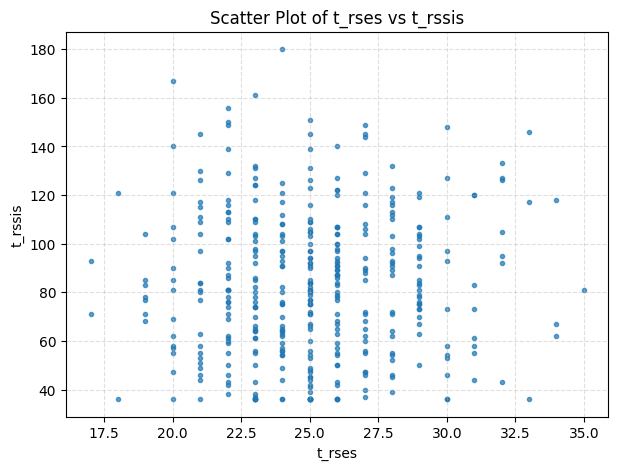

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
plt.scatter(t_rses, t_rssis, alpha=0.7, marker='.')
plt.xlabel("t_rses")
plt.ylabel("t_rssis")
plt.title("Scatter Plot of t_rses vs t_rssis")
plt.grid(True, linestyle="--", alpha=0.4)
# plt.gca().set_aspect("equal", adjustable="box")
plt.show()

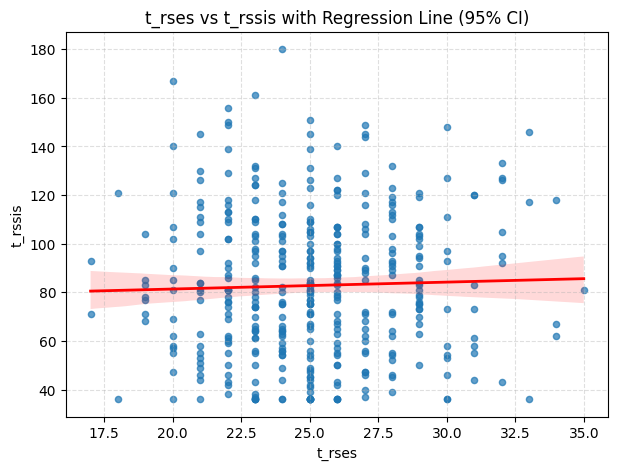

In [14]:
import seaborn as sns

plt.figure(figsize=(7, 5))
sns.regplot(
    x=t_rses,
    y=t_rssis,
    ci=95,
    scatter_kws={"alpha": 0.7, "s": 20},
    line_kws={"color": "red", "linewidth": 2},
)

plt.xlabel("t_rses")
plt.ylabel("t_rssis")
plt.title("t_rses vs t_rssis with Regression Line (95% CI)")
plt.grid(True, linestyle="--", alpha=0.4)
# plt.gca().set_aspect("equal", adjustable="box")

plt.show()

In [9]:
t_rses_std = (t_rses - t_rses.mean()) / t_rses.std(ddof=0)
t_rssis_std = (t_rssis - t_rssis.mean()) / t_rssis.std(ddof=0)
t_iss_std = (t_iss - t_iss.mean()) / t_iss.std(ddof=0)

print("First 5 standardized values:")
print("t_rses_std:\n", t_rses_std.head())
print("\nt_rssis_std:\n", t_rssis_std.head())
print("\nt_iss_std:\n", t_iss_std.head())

First 5 standardized values:
t_rses_std:
 0    1.853523
1   -0.020612
2   -0.020612
3   -0.332968
4    0.291744
dtype: float64

t_rssis_std:
 0   -0.329694
1   -0.902828
2    0.041158
3   -0.666831
4   -1.577104
dtype: float64

t_iss_std:
 0   -1.509477
1    0.455658
2    0.174924
3    0.174924
4    0.174924
dtype: float64


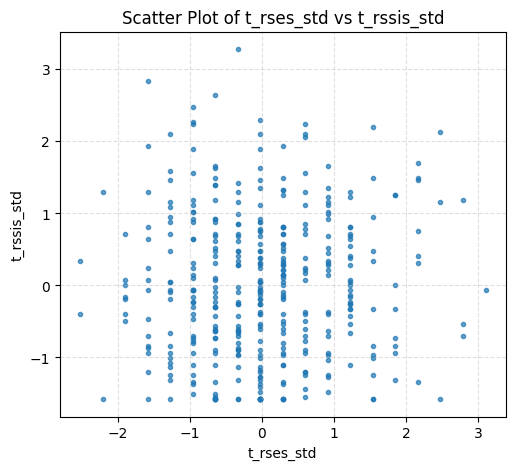

In [10]:
plt.figure(figsize=(7, 5))
plt.scatter(t_rses_std, t_rssis_std, alpha=0.7, marker=".")
plt.xlabel("t_rses_std")
plt.ylabel("t_rssis_std")
plt.title("Scatter Plot of t_rses_std vs t_rssis_std")
plt.grid(True, linestyle="--", alpha=0.4)
plt.gca().set_aspect("equal", adjustable="box")
plt.show()